#ML project
##The Datasets We use it



 **Group Member:**

**Maha Ahmed - 445014009**

**Lujain Omar – s445005807**

**Wareef Saad – s445006546**

**Mirana Mohammad – s445005808**

**Hebah fahad AL matrafi -
s444010917**

**Supervisor: Dr. Afaf Almehmadi**

#Step 1:Loding All Libraries We need:



In [ ]:
!pip install lightgbm --quiet
!pip install pandas numpy --quiet

import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from lightgbm import LGBMRegressor, LGBMClassifier
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 34.1 MB/s eta 0:00:00


# Step 2: Data cleaning and preparation



In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

# Reading train and test files from Google Drive (simplified version without the rest of the tables)
train = pd.read_csv('/content/drive/MyDrive/train.csv', parse_dates=['date'], low_memory=False, nrows=13_000_000)

test = pd.read_csv('/content/drive/MyDrive/forcasting_salse/test.csv', parse_dates=['date'])


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13000000 entries, 0 to 12999999
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   item_nbr     int64         
 4   unit_sales   float64       
 5   onpromotion  float64       
dtypes: datetime64[ns](1), float64(2), int64(3)
memory usage: 595.1 MB


In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3370464 entries, 0 to 3370463
Data columns (total 5 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   item_nbr     int64         
 4   onpromotion  bool          
dtypes: bool(1), datetime64[ns](1), int64(3)
memory usage: 106.1 MB


In [ ]:
# For the Favorita dataset, the target column is 'unit_sales'
train['sales'] = train['unit_sales']  # create canonical target column
train['sales'] = train['sales'].astype(float)
train = train.drop('unit_sales', axis=1)

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13000000 entries, 0 to 12999999
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   item_nbr     int64         
 4   onpromotion  float64       
 5   sales        float64       
dtypes: datetime64[ns](1), float64(2), int64(3)
memory usage: 595.1 MB


In [ ]:
# After read train
df = train.copy()

In [ ]:
df.head()

,id,date,store_nbr,item_nbr,onpromotion,sales
0,0,2013-01-01,25,103665,NaN,7.0
1,1,2013-01-01,25,105574,NaN,1.0
2,2,2013-01-01,25,105575,NaN,2.0
3,3,2013-01-01,25,108079,NaN,1.0
4,4,2013-01-01,25,108701,NaN,1.0


In [ ]:
CountNan = [x for x in df if df[x].isnull().sum() > 0] ## This creates a list of column names that have at least one missing value
df[CountNan].isnull().sum() # Display the count of missing values

,0
onpromotion,13000000


In [ ]:
# there is no values in onpromotion column. So, we drop it
df = df.drop('onpromotion', axis=1)


In [ ]:
# Basic temporal features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofweek'] = df['date'].dt.dayofweek
df['weekofyear'] = df['date'].dt.isocalendar().week.astype(int)
df['is_weekend'] = df['dayofweek'].isin([5,6]).astype(int)
df['is_month_start'] = df['date'].dt.is_month_start.astype(int)
df['is_month_end'] = df['date'].dt.is_month_end.astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13000000 entries, 0 to 12999999
Data columns (total 13 columns):
 #   Column          Dtype         
---  ------          -----         
 0   id              int64         
 1   date            datetime64[ns]
 2   store_nbr       int64         
 3   item_nbr        int64         
 4   sales           float64       
 5   year            int32         
 6   month           int32         
 7   day             int32         
 8   dayofweek       int32         
 9   weekofyear      int64         
 10  is_weekend      int64         
 11  is_month_start  int64         
 12  is_month_end    int64         
dtypes: datetime64[ns](1), float64(1), int32(4), int64(7)
memory usage: 1.1 GB


In [ ]:
df['sales'].describe()

,sales
count,1.300000e+07
mean,8.446063e+00
std,1.795879e+01
min,-2.070000e+02
25%,2.000000e+00
50%,4.000000e+00
75%,9.000000e+00
max,1.007400e+04


In [ ]:
# Fix negative sales before creating features
df['sales'] = df['sales'].clip(lower=0)

# Lag & rolling features at the (store_nbr, item_nbr) level
df = df.sort_values(['store_nbr','item_nbr','date'])

# Ensure the target column is present
if 'sales' not in df.columns:
    raise ValueError("Target column 'sales' not found")

# Creating (Lag features)
for lag in [7, 14, 28]:
    df[f'sales_lag_{lag}'] = df.groupby(['store_nbr','item_nbr'])['sales'].shift(lag)
    df[f'sales_lag_{lag}'] = df[f'sales_lag_{lag}'].fillna(0)

# Creating (Rolling features)
for window in [7, 14]:
    df[f'sales_rolling_mean_{window}'] = df.groupby(['store_nbr','item_nbr'])['sales'].transform(
        lambda x: x.rolling(window, 1).mean()
    )
    df[f'sales_rolling_std_{window}'] = df.groupby(['store_nbr','item_nbr'])['sales'].transform(
        lambda x: x.rolling(window, 1).std().fillna(0)
    )

In [ ]:
# Choosing the features we will use in the model
features = [
    'store_nbr','item_nbr',  # Columns from train
    'year','month','day','dayofweek','weekofyear',
    'is_weekend','is_month_start','is_month_end',
    'sales_lag_7','sales_lag_14','sales_lag_28',
    'sales_rolling_mean_7','sales_rolling_mean_14','sales_rolling_std_7'
]
target = 'sales'

# Checking the presence of all columns
missing = [c for c in features if c not in df.columns]
if missing:
    print("The following columns are missing and need to be handled:", missing)
else:
    print("All required columns are present")


All required columns are present


In [ ]:
# Converting some columns to a categorical type for the benefit of LightGBM
categorical_cols = [
    'store_nbr','item_nbr',
    'is_weekend','is_month_start','is_month_end'
]


In [ ]:
# Temporal split: 80% training - 20% validation
split_date = df['date'].quantile(0.8)
train_mask = df['date'] <= split_date
test_mask = df['date'] > split_date

X_train = df.loc[train_mask, features]
y_train = df.loc[train_mask, 'sales']
X_test = df.loc[test_mask, features]
y_test = df.loc[test_mask, 'sales']

In [ ]:
# Convert categorical columns
for col in categorical_cols:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')


📊 Target Statistics:


,sales
count,1.040580e+07
mean,8.439172e+00
std,1.833456e+01
min,0.000000e+00
25%,2.000000e+00
50%,4.000000e+00
75%,9.000000e+00
max,1.007400e+04


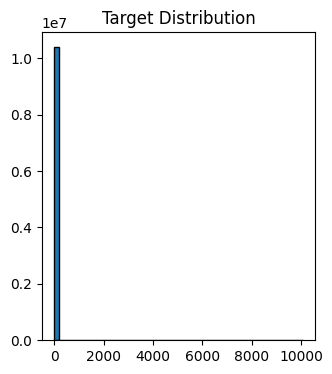

In [ ]:
#1. Check the target distribution
plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.hist(y_train, bins=50, edgecolor='black')
plt.title('Target Distribution')

#2. Check the scale of values
print(f"\n📊 Target Statistics:")
y_train.describe()

above output indicate highly skewed data with significant outliers

LightGBM Core Parameters:
https://lightgbm.readthedocs.io/en/latest/Parameters.html

#Step 3: Train and Test



```
# Setup LightGBM
train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_cols)
val_data = lgb.Dataset(X_test, label=y_test, categorical_feature=categorical_cols, reference=train_data)

params = {
    'objective':'regression',
    'metric':'rmse',
    'learning_rate':0.1,
    'num_leaves':63,
    'max_depth':-1,
    'min_data_in_leaf':20,
    'feature_fraction':0.8,
    'bagging_fraction':0.8,
    'bagging_freq':5,
    'verbosity':-1,
    'seed':42
}
start_time = time.time()
model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[train_data, val_data],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)
```

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[36]	training's rmse: 9.97782	valid_1's rmse: 8.52571

In [ ]:
# Setup LightGBM
train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_cols)
val_data   = lgb.Dataset(X_test,  label=y_test,  categorical_feature=categorical_cols, reference=train_data)

params = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.015,   # Slower = Learn more accurately
    "num_leaves": 90,        # A slightly deeper tree for learning difficult patterns
    "max_depth": -1,
    "min_data_in_leaf": 40,   # Prevents simple overfitting
    'min_child_samples': 30, # Reduces the impact of extreme values
    "feature_fraction": 0.85, # Uses most features with a bit of randomness
    "bagging_fraction": 0.8,
    "bagging_freq": 7,
    "lambda_l1": 1.5,         # Regularization is stronger
    "lambda_l2": 2.0,
    "verbosity": -1,
    "seed": 42
}

model = lgb.train(
    params,
    train_data,
    num_boost_round=2000,
    valid_sets=[train_data, val_data],
    callbacks=[
        lgb.early_stopping(200),
        lgb.log_evaluation(100)
    ]
)

Training until validation scores don't improve for 200 rounds
[100]	training's rmse: 11.5302	valid_1's rmse: 8.9023
[200]	training's rmse: 10.5855	valid_1's rmse: 8.26059
[300]	training's rmse: 10.1424	valid_1's rmse: 8.2243
[400]	training's rmse: 9.8305	valid_1's rmse: 8.25927
Early stopping, best iteration is:
[278]	training's rmse: 10.2293	valid_1's rmse: 8.21663


In [ ]:
# Feature importance
importance_df = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importance()
}).sort_values("importance", ascending=False)

print("Top features by importance:\n")
print(importance_df.head(15))

Top features by importance:

                  feature  importance
1                item_nbr        3050
5               dayofweek        2948
10            sales_lag_7        2665
4                     day        2632
13   sales_rolling_mean_7        2609
11           sales_lag_14        2569
0               store_nbr        2289
12           sales_lag_28        2089
15    sales_rolling_std_7        1913
6              weekofyear         802
14  sales_rolling_mean_14         446
7              is_weekend         321
3                   month         267
8          is_month_start         142
2                    year           0


In [ ]:
# Model evaluation
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2: {r2:.2f}")

RMSE: 8.22
MAE: 3.01
R2: 0.75


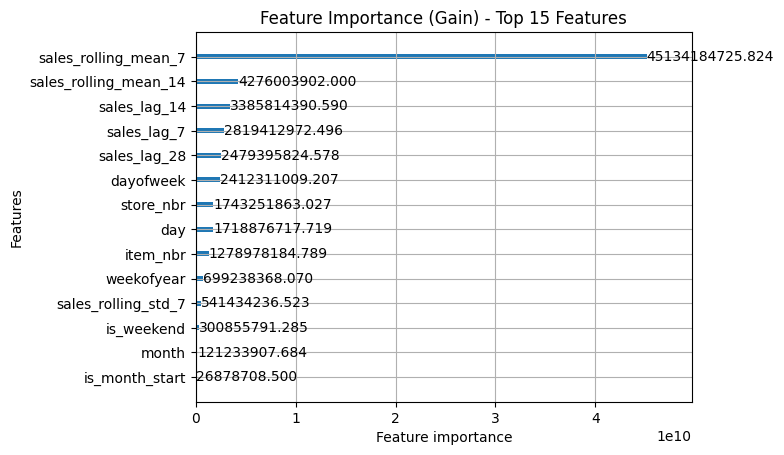

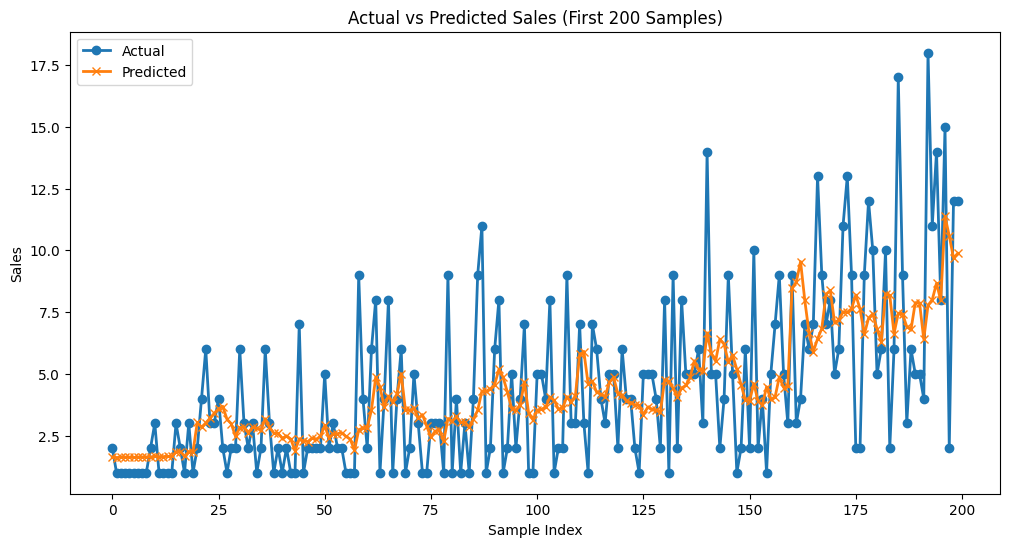

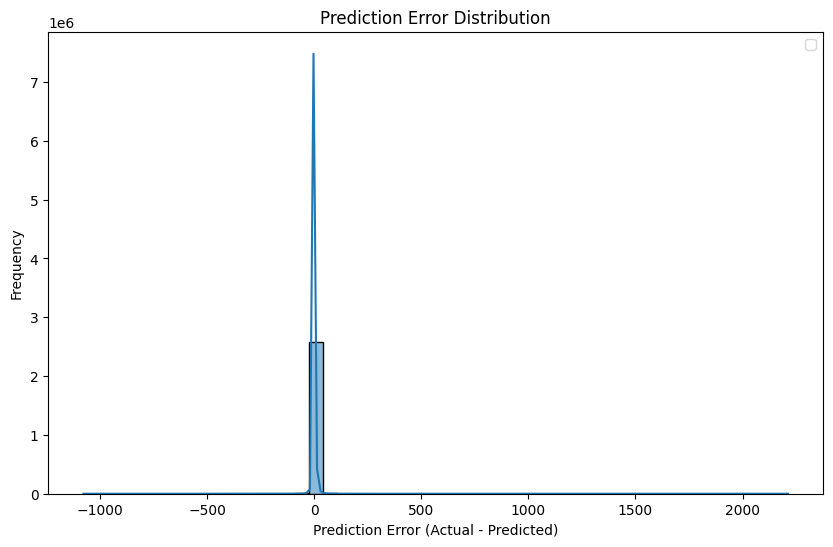

ERROR ANALYSIS
Mean Error: -0.01
Standard Deviation of Error: 8.22
Minimum Error: -1078.37
Maximum Error: 2212.07
Mean Absolute Error: 3.01
Percentage of errors within ±10: 95.3%
Percentage of errors within ±20: 98.8%


In [ ]:
# Feature importance visualization with better formatting
lgb.plot_importance(model, max_num_features=15, importance_type='gain', title='Feature Importance (Gain) - Top 15 Features')
plt.show()

# Actual vs Predicted comparison plot for first 200 samples
plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:200], label='Actual', marker='o', linewidth=2)
plt.plot(y_pred[:200], label='Predicted', marker='x', linewidth=2)
plt.title("Actual vs Predicted Sales (First 200 Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Sales")
plt.legend()
plt.show()

# Prediction error distribution histogram
errors = y_test.values - y_pred
plt.figure(figsize=(10, 6))
sns.histplot(errors, bins=50, kde=True)
plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Error statistics
print("ERROR ANALYSIS")
print(f"Mean Error: {errors.mean():.2f}")
print(f"Standard Deviation of Error: {errors.std():.2f}")
print(f"Minimum Error: {errors.min():.2f}")
print(f"Maximum Error: {errors.max():.2f}")
print(f"Mean Absolute Error: {np.mean(np.abs(errors)):.2f}")
print(f"Percentage of errors within ±10: {(np.abs(errors) <= 10).sum() / len(errors) * 100:.1f}%")
print(f"Percentage of errors within ±20: {(np.abs(errors) <= 20).sum() / len(errors) * 100:.1f}%")


transformed the regression into a class prediction by creating sales bins
Sales were divided into four bins:

**0    :     0**

**1	   :    1–5**

**2	   :    6–20**

**3	   :    21+**



CONFUSION MATRIX:
[[      0      77      41       4]
 [      1 1232101  292951    2678]
 [      2  146962  652484   41818]
 [      0     167   58550  166362]]

Accuracy: 0.7906

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       122
           1       0.89      0.81      0.85   1527731
           2       0.65      0.78      0.71    841266
           3       0.79      0.74      0.76    225079

    accuracy                           0.79   2594198
   macro avg       0.58      0.58      0.58   2594198
weighted avg       0.81      0.79      0.79   2594198



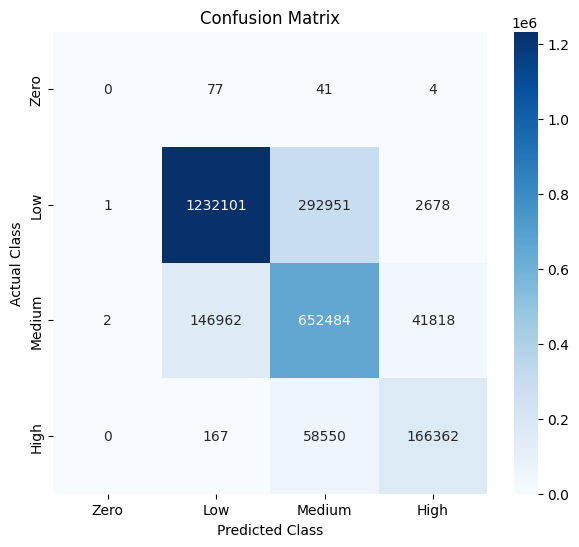

In [ ]:
# 1) Clean predictions before binning
y_pred_clean = np.nan_to_num(y_pred, nan=0.0)   # Replace NaN with 0
y_pred_clean = np.clip(y_pred_clean, 0, None)    # Replace negative values with 0

# 2) Convert continuous sales to categories (Binning)
def convert_to_classes(values):
    bins = [-1, 0, 5, 20, np.inf]
    labels = [0, 1, 2, 3]
    return pd.cut(values, bins=bins, labels=labels).astype(int)

y_test_class = convert_to_classes(y_test.values)
y_pred_class = convert_to_classes(y_pred_clean)

# 3) Confusion Matrix
cm = confusion_matrix(y_test_class, y_pred_class)
print("\nCONFUSION MATRIX:")
print(cm)

# 4) Accuracy
acc = accuracy_score(y_test_class, y_pred_class)
print(f"\nAccuracy: {acc:.4f}")

# 5) Full Classification Report
print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test_class, y_pred_class))

# 6) Plot confusion matrix
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Zero", "Low", "Medium", "High"],
    yticklabels=["Zero", "Low", "Medium", "High"]
)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")
plt.show()
